# Buổi 11 — Ngoại lai và điểm gãy

**Một câu:** điểm "lạ" có bốn loại khác nhau; ngưỡng 3σ tự mù trước chúng, MAD và Hampel thì không; sự kiện thật như Tết phải giữ nhờ
nhật ký sự kiện; chỗ chuỗi đổi hẳn thì tìm bằng PELT — và cách xử lý một đoạn bất thường là một giả định về tương lai.

Tình huống: lượt xem Wikipedia tiếng Việt 2016–2025 (tổng, và bài "Tết Nguyên Đán") cùng hành khách hàng không 27 nước EU từ 2008.
Muốn làm sạch để dự báo — nhưng sạch cái gì, và giữ cái gì?

| Phần | Câu hỏi |
|---|---|
| 1 | "Ngoại lai" có mấy loại, nhận ra loại bằng gì? |
| 2 | Vì sao ngưỡng 3σ bỏ sót chính ngoại lai lớn? |
| 3 | Thước đo nào ngoại lai không kéo được, và so với mức nào? |
| 4 | Đỉnh Tết bị gắn cờ — có sửa không? |
| 5 | Chuỗi đổi hẳn ở mốc nào, và chọn penalty ra sao? |
| 6 | COVID là ngoại lai, dịch mức hay bình thường mới? |

## 0. Dữ liệu

**Bộ dữ liệu Wikimedia Pageviews — Wikipedia tiếng Việt.** Số **lượt xem mỗi ngày** trên Wikipedia tiếng Việt 2016–2025, do Wikimedia đếm (chỉ người thật — `agent=user`, bỏ bot
đã nhận diện). Hai tệp JSON: bài "Tết Nguyên Đán" (`wikipedia-vi-tet`) và tổng lượt xem cả trang tiếng Việt
(`wikipedia-vi-tong`). Mỗi phần tử của danh sách `items` là **một ngày**.

Nguồn: Wikimedia Foundation, Pageviews API (truy cập 2026-09-17); và 1 tệp cùng họ. Giấy phép CC0 1.0.

| Cột | Nghĩa |
|---|---|
| `timestamp` | ngày, dạng `2016010100` (năm, tháng, ngày, giờ 00) |
| `views` | số lượt xem trong ngày |

**Bộ dữ liệu Eurostat avia_paoc — hành khách hàng không EU27.** Số **hành khách đi máy bay mỗi tháng** của 27 nước EU cộng lại, từ 1/2008, do Eurostat (cơ quan thống kê EU) tổng hợp
từ báo cáo của các sân bay. Tệp CSV, mỗi dòng là **một tháng**; các cột đầu lặp lại mã phân loại giống nhau ở mọi dòng. Tháng
4/2020 số khách giảm gần 99% so với 4/2019 vì COVID-19.

Nguồn: Eurostat, Air passenger transport by type of schedule (avia_paoc), truy cập 2026-09-18. Giấy phép CC BY 4.0 (Eurostat).

| Cột | Nghĩa |
|---|---|
| `TIME_PERIOD` | tháng, dạng `2008-01` |
| `OBS_VALUE` | số hành khách trong tháng |
| `freq`, `unit`, `tra_meas`, `geo…` | mã phân loại: tháng, đơn vị hành khách, hành khách chở có thu tiền, EU27 |

Ô dưới tải dữ liệu (1 MB) một lần rồi kiểm **sha256** — "dấu vân tay" tính từ nội dung tệp, sai một byte là ra chuỗi khác hẳn. Khớp nghĩa là bạn đang có đúng tệp mà mọi con số dưới đây được tính ra.

In [ ]:
import hashlib
import os
import urllib.request
from pathlib import Path

# tên bộ: (sha256, [nơi tải, thử lần lượt])
DU_LIEU = {
    "wikipedia-vi-tet": ("8f9e15ea30553c66999c204119a99dd973c2c130bdd2e21acbfd642f0db9ca4e", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/wikipedia-vi-tet/tet-nguyen-dan-2016-2025.json",
        "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/vi.wikipedia/all-access/user/T%E1%BA%BFt_Nguy%C3%AAn_%C4%90%C3%A1n/daily/2016010100/2025123100",
    ]),
    "wikipedia-vi-tong": ("481d604d1b581efcb76c4a86d1dc6e5547271c6b8e2a772bcc53719b1fa1c3f3", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/wikipedia-vi-tong/vi-wikipedia-tong-2016-2025.json",
        "https://wikimedia.org/api/rest_v1/metrics/pageviews/aggregate/vi.wikipedia/all-access/user/daily/2016010100/2025123100",
    ]),
    "eurostat-hanh-khach-hang-khong": ("6ce5178cf876ba9e58c47ed9e6c5c4207383e9041dab1fc9306693c691eff5d0", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/eurostat-hanh-khach-hang-khong/eurostat-avia-paoc-eu27.csv",
        "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/avia_paoc/1.0/M.PAS.PAS_CRD.TOTAL.TOTAL.EU27_2020?format=csvdata&compress=false",
    ]),
}
CACHE = Path(os.environ.get("KHOA_FORECASTING_CACHE") or Path.home() / ".cache" / "khoa-forecasting")


def sha256(tep: Path) -> str:
    h = hashlib.sha256()
    with open(tep, "rb") as f:
        for khoi in iter(lambda: f.read(1 << 20), b""):
            h.update(khoi)
    return h.hexdigest()


def lay(ten: str) -> Path:
    """Đường dẫn tệp đã kiểm sha256; chưa có thì tải về một lần."""
    sha, urls = DU_LIEU[ten]
    tep = CACHE / "sha256" / sha[:2] / sha
    if tep.is_file() and sha256(tep) == sha:
        return tep
    tep.parent.mkdir(parents=True, exist_ok=True)
    for url in urls:
        try:
            urllib.request.urlretrieve(url, tep)
            if sha256(tep) == sha:
                return tep
            print("sha256 không khớp:", url)
        except OSError as loi:
            print("tải lỗi:", url, loi)
    raise RuntimeError(f"không tải được {ten} khớp sha256")


for ten in DU_LIEU:
    print(f"{ten:<28} {lay(ten)}")

In [ ]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ruptures as rpt
from statsmodels.tsa.seasonal import STL

warnings.simplefilter("ignore")
HE_SO_MAD = 1.4826                     # đưa MAD về cùng thang với độ lệch chuẩn khi dữ liệu hình chuông


def doc_pageviews(ten):
    muc = json.loads(lay(ten).read_text(encoding="utf-8"))["items"]
    moc = pd.to_datetime([m["timestamp"][:8] for m in muc], format="%Y%m%d")
    return pd.Series([m["views"] for m in muc], index=moc, name="views").sort_index()


tong, tet = doc_pageviews("wikipedia-vi-tong"), doc_pageviews("wikipedia-vi-tet")
d = pd.read_csv(lay("eurostat-hanh-khach-hang-khong"))
hk = pd.Series(d["OBS_VALUE"].to_numpy(float),
               index=pd.PeriodIndex(d["TIME_PERIOD"], freq="M").to_timestamp()).sort_index()
print(f"Wikipedia tổng: {len(tong):,} ngày | bài Tết: {len(tet):,} ngày | "
      f"hàng không EU: {len(hk)} tháng, {hk.index[0]:%m/%Y} → {hk.index[-1]:%m/%Y}")

## 1. Loại bất thường lộ ra ở các điểm sau, không ở điểm lệch

**Vấn đề.** Gõ nhầm, mở thêm quầy, khuyến mãi, thay cảm biến: cả bốn làm chuỗi "lạ" ở một mốc, nhưng mỗi cái cần xử lý khác.

> **ngoại lai (outlier)** · *outlier*
>
> - **Là gì:** giá trị lệch hẳn khỏi phần còn lại, do lỗi đo hay do sự kiện thật.
> - **Ví dụ:** 10, 12, 11, **50**, 12.
> - **Để làm gì:** quyết định sửa, giữ hay mô hình hoá riêng trước khi nó kéo lệch mô hình.
>
> 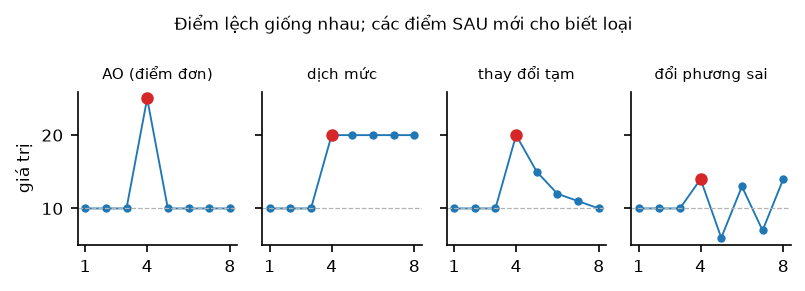

> **AO (điểm đơn)** · *additive outlier*
>
> - **Là gì:** một điểm lệch, trước và sau vẫn như cũ.
> - **Ví dụ:** 10, 10, 10, **25**, 10, 10: gõ nhầm, hay một ngày cảm biến chập.
> - **Để làm gì:** loại duy nhất sửa được bằng cách thay đúng điểm đó.

> **dịch mức (LS, level shift)** · *level shift*
>
> - **Là gì:** mức trung bình đổi đột ngột rồi giữ luôn ở mức mới.
> - **Ví dụ:** mở thêm quầy từ tháng 3: bán quanh 130 thay vì 100.
> - **Để làm gì:** mọi dự báo sau mốc phải dùng mức mới; sửa nó như lỗi là xoá sự thật.

> **thay đổi tạm (TC)** · *temporary change*
>
> - **Là gì:** mức nhảy rồi hồi dần về như cũ.
> - **Ví dụ:** khuyến mãi một tuần: 10, **20**, 15, 12, 11, 10.
> - **Để làm gì:** dự báo ngay sau mốc phải tính phần hồi dần.

> **đổi phương sai** · *variance change*
>
> - **Là gì:** mức giữ nguyên, độ dao động đổi.
> - **Ví dụ:** thay cảm biến kém chính xác: vẫn quanh 10 nhưng dao động ±4 thay vì ±0,5.
> - **Để làm gì:** khoảng dự báo phải nở ra (hoặc co lại) theo; mức thì không cần sửa.

**Lý do.** Bốn loại khác nhau ở chỗ chuỗi làm gì **sau** mốc lạ. Ngưỡng nhìn từng điểm chỉ bắt được AO; dịch mức và thay đổi tạm cần
tìm điểm gãy (phần 5); đổi phương sai cần đo độ dao động của phần dư.

**Kết quả.** Bốn chuỗi 8 điểm, mức nền 10 (số minh hoạ):

In [ ]:
bon = {"AO (điểm đơn)": [10, 10, 10, 25, 10, 10, 10, 10], "dịch mức": [10, 10, 10, 20, 20, 20, 20, 20],
       "thay đổi tạm": [10, 10, 10, 20, 15, 12, 11, 10], "đổi phương sai": [10, 10, 10, 14, 6, 13, 7, 14]}
print(pd.DataFrame({ten: {"điểm 4": v[3], "TB 4 điểm sau": np.mean(v[4:]), "điểm cuối": v[-1],
                          "độ lệch chuẩn 4 điểm sau": round(np.std(v[4:], ddof=1), 2)} for ten, v in bon.items()}).T)


def sinh_chuoi_co_loi(n=400, seed=0):
    # chuỗi mô phỏng có nhãn biết trước: xu hướng + mùa vụ tuần + nhiễu, cài sáu bất thường
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    y = 100 + 0.05 * t + 8 * np.sin(2 * np.pi * t / 7) + rng.normal(0, 2, n)
    nhan = {"outlier_cong": [50, 120, 300], "level_shift": [200], "thay_doi_tam": [260], "doi_phuong_sai": [340]}
    y[nhan["outlier_cong"]] += 40
    y[200:] += 25
    for i, k in enumerate(range(260, 280)):
        y[k] += 30 * 0.85**i
    y[340:] += rng.normal(0, 8, n - 340)
    return pd.Series(y, index=pd.date_range("2023-01-01", periods=n, freq="D")), nhan


mo, nhan = sinh_chuoi_co_loi()
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(mo, color="0.5", lw=0.8)
for ten, cac_i in nhan.items():
    ax.plot(mo.index[cac_i], mo.iloc[cac_i], "*", ms=10, label=ten)
ax.set(ylabel="giá trị", title="Chuỗi mô phỏng 400 ngày (seed 0): sáu bất thường cài sẵn, bốn loại")
ax.legend(fontsize=8, ncol=4)
plt.show()

Cột "điểm 4" không tách được ba dòng đầu; bốn điểm sau thì tách: AO về 10, dịch mức ở lại 20, thay đổi tạm hồi dần. Dòng cuối vẫn trung
bình 10 nhưng độ lệch chuẩn 4,08. Phần 5 gắn nhãn chuỗi mô phỏng này bằng máy.

**Bài học.** Hỏi "loại gì" trước "lớn cỡ nào": loại quyết định cách phát hiện và cách xử lý.

## 2. Ngưỡng 3σ tự mù: ngoại lai kéo chính thước đo

**Vấn đề.** Cách quen thuộc: gắn cờ khi $|z| > 3$. Nhưng trung bình và độ lệch chuẩn tính trên chính dữ liệu đang có ngoại lai.

> **z-score**
>
> - **Là gì:** khoảng cách tới trung bình tính bằng số lần độ lệch chuẩn: $z = (y - \bar y)/s$; thường gắn cờ khi $|z| > 3$.
> - **Ví dụ:** trung bình 10, $s$ = 2, giá trị 16 → $z$ = 3.
> - **Để làm gì:** thước đo "lạ" quen thuộc nhất; chỉ đúng khi dữ liệu gần hình chuông, ít ngoại lai, không xu hướng.

> **masking / swamping**
>
> - **Là gì:** masking: ngoại lai kéo trung bình và độ lệch chuẩn lên nên che chính nó và các ngoại lai khác. Swamping: chiều ngược lại, ngoại lai làm điểm bình thường bị gắn cờ oan.
> - **Ví dụ:** thêm số 60 vào dãy đã có 50: $z$ của 50 tụt từ 2,84 xuống 1,61.
> - **Để làm gì:** nhắc rằng "không vượt 3σ" không có nghĩa "không có ngoại lai".

**Lý do.** Ngoại lai càng lớn càng kéo $\bar y$ và $s$ lên theo: với $n$ số, $|z|$ không bao giờ vượt $(n-1)/\sqrt n$. Mười số thì trần là
2,85 — ngưỡng 3 không bao giờ chạm tới.

**Kết quả.** Mười số, một rồi hai ngoại lai; rồi 3.653 ngày Wikipedia trước và sau khi thêm **một** ngày giả bằng 8 lần ngày cao nhất:

In [ ]:
def z_score(y, nguong=3.0):
    return ((y - y.mean()) / y.std()).abs() > nguong


mot = np.array([10, 12, 11, 13, 12, 50, 11, 12, 13, 12.0])
hai = mot.copy()
hai[9] = 60
for ten, v in (("một ngoại lai", mot), ("hai ngoại lai", hai)):
    z = (v - v.mean()) / v.std(ddof=1)
    print(f"{ten}: trung bình {v.mean():.1f}, s {v.std(ddof=1):.1f}, z của 50 = {z[5]:.2f}, z lớn nhất = {z.max():.2f}")
print(f"trần của |z| với n = 10: {9 / np.sqrt(10):.2f}")

them = tong.copy()
them.iloc[len(tong) // 2] = tong.max() * 8
for ten, y in (("gốc", tong), ("thêm 1 ngày giả", them)):
    print(f"Wikipedia, {ten:<15}: ngưỡng TB + 3σ = {(y.mean() + 3 * y.std()) / 1e6:.2f} triệu → {z_score(y).sum()} ngày bị gắn cờ")

Một ngoại lai: $z$ của 50 chỉ 2,84, không bị bắt. Thêm 60, hai số che nhau: 1,61 và 2,15. Trên dữ liệu thật, một ngày giả đẩy
ngưỡng 3σ lên và số ngày bị gắn cờ tụt từ 16 xuống 5 — mười một ngày "bất thường" biến mất chỉ vì thước đo đổi.

**Bài học.** Trước khi tin một ngưỡng, thêm thử một điểm cực lớn: số cờ tụt là ngưỡng đang bị ngoại lai kéo.

## 3. MAD và Hampel: đo bằng trung vị, so với mức quanh điểm

**Vấn đề.** Cần thước đo mà vài điểm cực lớn không kéo được. Và lượt xem Wikipedia có xu hướng: trung bình cả chuỗi không đại diện cho
ngày nào.

> **MAD** · *median absolute deviation*
>
> - **Là gì:** trung vị của |khoảng cách tới trung vị|, nhân 1,4826 để cùng thang với độ lệch chuẩn. Điểm MAD = |y − trung vị| / MAD.
> - **Ví dụ:** dãy 10 số có số 50: trung vị 12, MAD 1,48; điểm của 50 = 38 / 1,48 ≈ 25,6.
> - **Để làm gì:** đo độ dao động mà vài điểm cực lớn không kéo được — thay độ lệch chuẩn khi tìm ngoại lai.
>
> 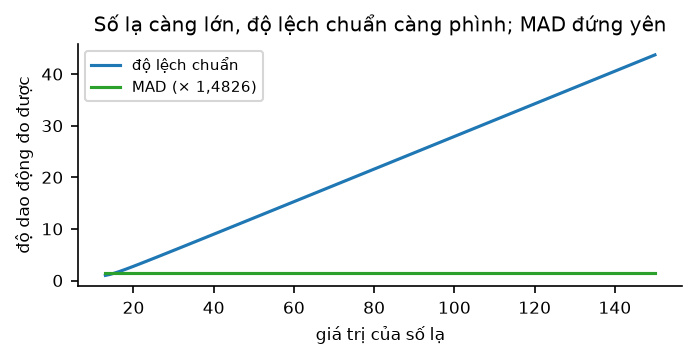

> **bộ lọc Hampel** · *Hampel filter*
>
> - **Là gì:** điểm MAD tính trên **cửa sổ trượt** ±$k$ điểm quanh mỗi điểm: so với trung vị và MAD địa phương.
> - **Ví dụ:** cửa sổ ±15 ngày: ngày 20/5 so với các ngày 5/5 → 4/6.
> - **Để làm gì:** tìm ngoại lai trên chuỗi có xu hướng hay mức đổi dần.
>
> 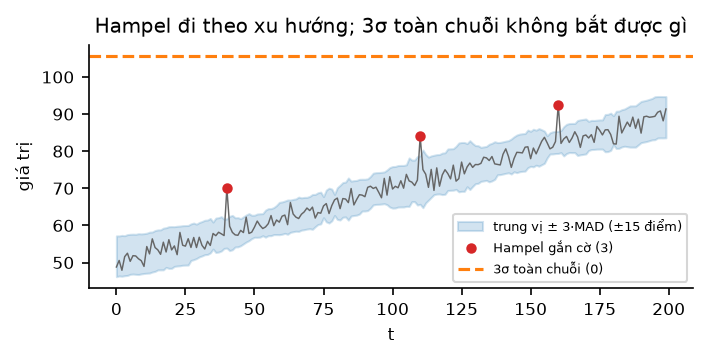

> **nhân quả / không nhân quả** · *causal / non-causal*
>
> - **Là gì:** nhân quả: kết quả tại $t$ chỉ dùng dữ liệu tới $t$. Không nhân quả: dùng cả dữ liệu sau $t$.
> - **Ví dụ:** Hampel ±15 ngày quanh 20/5 cần dữ liệu tới 4/6 → không nhân quả.
> - **Để làm gì:** phép không nhân quả chỉ để làm sạch lịch sử, không làm đặc trưng cho dự báo.

**Lý do.** Trung vị chỉ quan tâm một số nằm ở nửa trên hay nửa dưới, không quan tâm nó lớn cỡ nào. Hampel đặt MAD lên cửa sổ trượt nên
mức tham chiếu đi theo xu hướng; cửa sổ phải dài hơn dao động bình thường, ngắn hơn thay đổi cấu trúc.

**Kết quả.** Mười số, rồi năm cách gắn cờ trên 3.653 ngày Wikipedia:

In [ ]:
def mad_score(y):
    tv = y.median()
    mad = (y - tv).abs().median()
    return pd.Series(0.0, index=y.index) if mad == 0 else (y - tv).abs() / (HE_SO_MAD * mad)


def hampel(y, cua_so=15, nguong=3.0):
    k = 2 * cua_so + 1
    tv = y.rolling(k, center=True, min_periods=cua_so).median()
    mad = (y - tv).abs().rolling(k, center=True, min_periods=cua_so).median()
    return ((y - tv).abs() / (HE_SO_MAD * mad.replace(0, np.nan))).fillna(0) > nguong   # MAD = 0 → bỏ qua


def iqr(y, he_so=1.5):
    q1, q3 = y.quantile(0.25), y.quantile(0.75)
    return (y < q1 - he_so * (q3 - q1)) | (y > q3 + he_so * (q3 - q1))


def stl_robust(y, chu_ky=7, nguong=3.0):
    du = pd.Series(STL(y, period=chu_ky, robust=True).fit().resid, index=y.index)
    return mad_score(du) > nguong


diem = mad_score(pd.Series(mot))
print(f"10 số: trung vị {np.median(mot):.0f}, MAD {HE_SO_MAD * np.median(np.abs(mot - np.median(mot))):.2f}, "
      f"điểm của 50 = {diem[5]:.1f}, điểm của 10 = {diem[0]:.2f}")

CACH = {"3σ toàn chuỗi": z_score, "IQR 1,5": iqr, "MAD 3 toàn chuỗi": lambda y: mad_score(y) > 3,
        "Hampel ±15 ngày": hampel, "STL robust, mùa vụ tuần": stl_robust}
co = {ten: ham(tong) for ten, ham in CACH.items()}
print(pd.DataFrame({"số ngày gắn cờ": {t: int(c.sum()) for t, c in co.items()},
                    "tỷ lệ %": {t: round(c.mean() * 100, 2) for t, c in co.items()}}))
print(f"masking? Hampel: gốc {hampel(tong).sum()} ngày → thêm 1 ngày giả {hampel(them).sum()} ngày")

fig, (a, b) = plt.subplots(2, 1, figsize=(10, 3.8), sharex=True)
for ax, ten, mau in ((a, "3σ toàn chuỗi", "tab:orange"), (b, "Hampel ±15 ngày", "tab:blue")):
    ax.plot(tong / 1e6, color="0.6", lw=0.6)
    ax.scatter(tong.index[co[ten]], tong[co[ten]] / 1e6, color=mau, s=10, zorder=3)
    ax.set(ylabel="triệu lượt/ngày", title=f"{ten}: {co[ten].sum()} ngày")
plt.show()

Mười số: điểm MAD của 50 là 25,6, bắt ngay. Trên Wikipedia, ba cách toàn chuỗi gắn cờ 15–27 ngày dồn vào vùng mức cao — chúng đang nói
"những ngày này đông". Hampel gắn cờ 121 ngày rải đều mười năm, và gần như không đổi khi thêm ngày giả (121 → 123). STL robust gắn cờ
16,86% số ngày, quá nhiều: phần dư còn cả mùa vụ năm.

**Bài học.** Dùng MAD thay độ lệch chuẩn, Hampel khi chuỗi có xu hướng; xem ngưỡng gắn cờ bao nhiêu phần trăm dữ liệu trước khi tin nó.

## 4. Tết là sự kiện thật: ghi vào nhật ký, không sửa

**Vấn đề.** Bài "Tết Nguyên Đán" mỗi năm có một đỉnh gấp chục lần nền. Ngưỡng nào cũng gắn cờ nó — có sửa không?

> **nhật ký sự kiện** · *event log*
>
> - **Là gì:** danh sách mốc đã biết có sự kiện thật, không được sửa như lỗi.
> - **Ví dụ:** 10 ngày đỉnh Tết 2016–2025; đợt COVID 3/2020 – 6/2021.
> - **Để làm gì:** tách "lạ vì lỗi đo" khỏi "lạ vì chuyện thật đáng dự báo".

> **winsorize**
>
> - **Là gì:** kéo giá trị bị gắn cờ về một mức hợp lý (ở đây: trung vị địa phương), không xoá.
> - **Ví dụ:** (12, 11, 13, **90**, 12) → (12, 11, 13, **12**, 12), cột `da_sua` = 1 ở mốc 4.
> - **Để làm gì:** sửa điểm lỗi mà vẫn giữ đủ mốc thời gian.
>
> 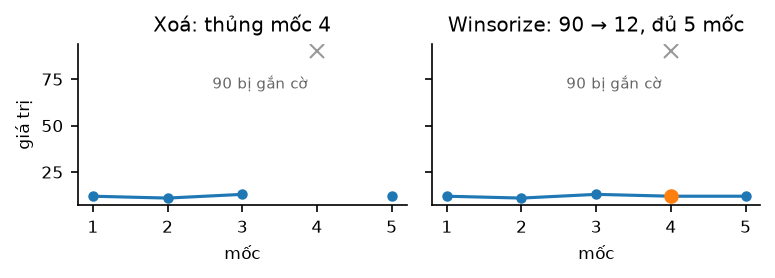

> **biến giả (dummy)** · *dummy variable*
>
> - **Là gì:** cột 0/1 báo mốc nào nằm trong một sự kiện, để mô hình học riêng ảnh hưởng của nó.
> - **Ví dụ:** `covid` = 1 từ 3/2020 tới 6/2021, còn lại 0.
> - **Để làm gì:** giữ dữ liệu thật mà mô hình không bị sự kiện kéo lệch; sự kiện lặp lại (Tết) còn dự báo được nhờ nó.

**Lý do.** Ngưỡng chỉ nói "khác", không biết khác vì lỗi đo hay vì chính điều ta muốn dự báo. STL cũng không học được đỉnh làm mùa vụ vì
Tết theo lịch âm. Chỉ nhật ký sự kiện phân biệt được; còn điểm lỗi thật thì winsorize, vì xoá làm thủng lưới thời gian.

**Kết quả.**

In [ ]:
dinh = [g.idxmax() for _, g in tet.groupby(tet.index.year)]           # đỉnh mỗi năm = ngày Tết
ngay_trong_nam = [d.dayofyear for d in dinh]
print("đỉnh Tết:", [f"{d:%d/%m/%Y}" for d in dinh])
print(f"ngày trong năm dương: {min(ngay_trong_nam)} → {max(ngay_trong_nam)} (xê dịch {max(ngay_trong_nam) - min(ngay_trong_nam)} ngày)")
for ten, ham in CACH.items():
    print(f"  {ten:<24} gắn cờ {sum(bool(ham(tet)[d]) for d in dinh)}/10 đỉnh")


def xu_ly_ngoai_lai(y, cua_so=15, bo_qua_su_kien=()):
    # gắn cờ bằng Hampel, bỏ qua mốc trong nhật ký sự kiện, winsorize về trung vị địa phương
    y = y.astype(float)
    co = hampel(y, cua_so) & ~y.index.isin(pd.DatetimeIndex(bo_qua_su_kien))
    tv = y.rolling(2 * cua_so + 1, center=True, min_periods=cua_so).median()
    sach = y.where(~co, tv)
    return pd.DataFrame({"y": y, "sach": sach, "da_sua": co})


tay = pd.Series([12, 11, 13, 90, 12.0])
co_tay = mad_score(tay) > 3
print("\nví dụ tay — xoá:", tay.where(~co_tay).tolist(), "| winsorize:", tay.where(~co_tay, tay.median()).tolist())
sai = tet.where(~z_score(tet)).dropna()                                   # cách sai: xoá mọi điểm vượt 3σ
print(f"xoá theo 3σ: còn {len(sai):,}/{len(tet):,} mốc, mất {sum(d not in sai.index for d in dinh)}/10 đỉnh Tết")
xl = xu_ly_ngoai_lai(tet, bo_qua_su_kien=dinh)
print(f"winsorize Hampel + nhật ký: còn {xl['sach'].notna().sum():,} mốc, sửa {xl['da_sua'].sum()} ngày, "
      f"10 đỉnh giữ nguyên: {(xl.loc[dinh, 'sach'] == tet[dinh]).all()}")

Cả năm cách gắn cờ 10/10 đỉnh; ngày dương của đỉnh xê dịch 25 ngày giữa các năm. Xoá theo 3σ mất 54 mốc, trong đó cả mười đỉnh.
Winsorize theo Hampel cộng nhật ký giữ đủ 3.653 mốc, mười đỉnh nguyên giá trị. Năm cách xử lý, chọn theo **loại**, không theo độ lớn:

| Cách | Hợp với |
|---|---|
| giữ + gắn cờ | sự kiện thật; khi chưa chắc |
| winsorize | AO do lỗi đo |
| coi là thiếu (NaN, rồi điền) | đoạn dữ liệu hỏng dài |
| biến giả | dịch mức, thay đổi tạm, sự kiện lặp lại |
| cắt dữ liệu cũ | cấu trúc đổi hẳn (phần 6) |

**Bài học.** Ngưỡng không phân biệt được lỗi đo với sự kiện thật; nhật ký sự kiện thì làm được. Sửa bằng winsorize hay biến giả, không xoá
mốc.

## 5. Điểm gãy phải trả phí: lấy log, rồi quét penalty

**Vấn đề.** Dịch mức và thay đổi tạm lộ ra ở chỗ chuỗi trước và sau một mốc khác nhau. Hành khách hàng không EU sụt rồi hồi phục quanh
COVID — ở những mốc nào?

> **điểm gãy (change point)** · *change point*
>
> - **Là gì:** mốc mà tính chất của chuỗi (mức, độ dao động) đổi.
> - **Ví dụ:** tháng 2/2020 với hành khách hàng không EU.
> - **Để làm gì:** thấy dịch mức và thay đổi tạm — hai loại mà ngưỡng từng điểm không thấy; biết từ đâu dữ liệu cũ còn đại diện.

> **hàm chi phí** · *cost function*
>
> - **Là gì:** con số đo một đoạn chuỗi "không đều" tới đâu; ở đây là tổng bình phương khoảng cách tới trung bình đoạn (chi phí l2).
> - **Ví dụ:** đoạn (10, 11, 10, 9, 10): trung bình 10, chi phí 0 + 1 + 0 + 1 + 0 = 2.
> - **Để làm gì:** cho thuật toán một thước để so các cách chia chuỗi.

> **PELT** · *Pruned Exact Linear Time*
>
> - **Là gì:** thuật toán tìm bộ điểm gãy làm tổng chi phí + phạt nhỏ nhất, chính xác mà nhanh nhờ loại sớm các vị trí chắc chắn không thắng.
> - **Ví dụ:** `ruptures.Pelt(model="l2").fit(v).predict(pen=6.9)` trên 10 số ví dụ → `[5, 10]`.
> - **Để làm gì:** tìm điểm gãy trên chuỗi lịch sử để làm sạch hay giải thích quá khứ.

> **penalty (phạt)** · *penalty*
>
> - **Là gì:** chi phí cộng thêm cho mỗi điểm gãy; phạt lớn thì ít điểm gãy. Quy ước hay dùng: $2 \ln n$ tới $3 \ln n$.
> - **Ví dụ:** $n$ = 10: $3 \ln 10 \approx 6{,}9$ — một điểm gãy chỉ được giữ nếu nó giảm chi phí hơn 6,9.
> - **Để làm gì:** chặn việc cắt vụn chuỗi tới mức mỗi điểm một đoạn.
>
> 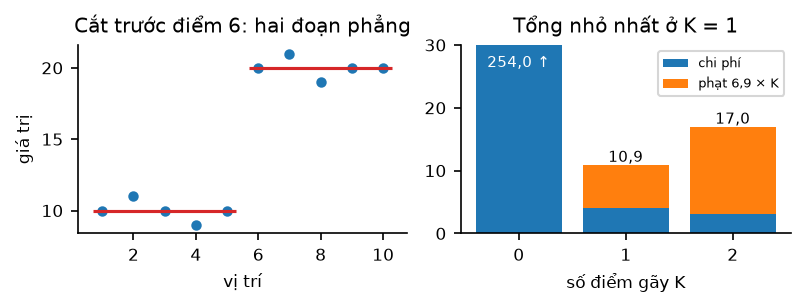

> **CUSUM, CROPS** · *cumulative sum, changepoints for a range of penalties*
>
> - **Là gì:** CUSUM cộng dồn độ lệch so với mức tham chiếu $\mu_0$, trừ dung sai $k$, không cho xuống dưới 0; báo động khi tổng vượt ngưỡng $h$. CROPS quét cả dải penalty — `ruptures` chưa có nên ta tự quét.
> - **Ví dụ:** $\mu_0$ = 10, $k$ = 0,5: ba ngày 11,5 liền nhau → tổng 1, 2, 3.
> - **Để làm gì:** CUSUM chạy được khi dữ liệu đang về, hợp để theo dõi mô hình; PELT cần cả chuỗi.
>
> 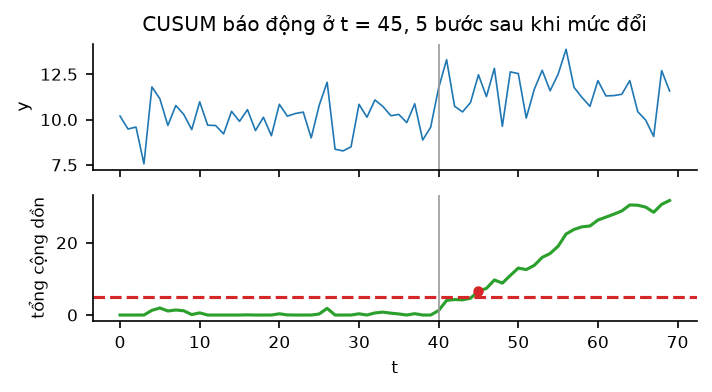

**Lý do.** Chia càng nhiều đoạn càng khớp, tới mức mỗi điểm một đoạn — vô nghĩa. Nên mỗi điểm gãy trả penalty $\beta$, và PELT tìm cách
chia có chi phí $+ \beta K$ nhỏ nhất. Chi phí cộng bình phương theo đơn vị của chuỗi, nên chuỗi tăng trưởng phải lấy log trước (không thì
mỗi mùa hè đông khách thành một đoạn). Và quét penalty: tin kết quả không đổi trong một khoảng rộng.

**Kết quả.** Ví dụ 10 số, rồi dữ liệu thật:

In [ ]:
v = np.array([10, 11, 10, 9, 10, 20, 21, 19, 20, 20.0])
beta = 3 * np.log(v.size)


def chi_phi(cat):                                     # tổng chi phí l2 của các đoạn khi cắt tại các vị trí trong `cat`
    return sum(((d - d.mean()) ** 2).sum() for d in np.split(v, cat))


for cat in ([], [5], [3, 5]):
    print(f"cắt tại {cat!s:<7}: chi phí {chi_phi(cat):6.2f} + phạt {beta * len(cat):5.2f} = {chi_phi(cat) + beta * len(cat):6.2f}")
print("ruptures:", rpt.Pelt(model="l2", min_size=2).fit(v).predict(pen=beta))


def diem_gay(y, pen=None, mo_hinh="l2", log=True):
    x = np.log(y.to_numpy(float)) if log else y.to_numpy(float)
    pen = 3 * np.log(x.size) if pen is None else pen
    return [y.index[i] for i in rpt.Pelt(model=mo_hinh, min_size=3).fit(x).predict(pen=pen)[:-1]]


ln_n = np.log(len(hk))
print(f"\nhàng không EU: mức gốc {len(diem_gay(hk, log=False))} điểm gãy | log {len(diem_gay(hk))} điểm gãy")
for he_so in (0.5, 1, 2, 3, 4, 6, 10):
    moc = diem_gay(hk, pen=he_so * ln_n)
    print(f"  penalty {he_so:>4} ln n: {len(moc)} điểm gãy {[f'{m:%m/%Y}' for m in moc][:4]}")
on_dinh = sorted(set.intersection(*[set(diem_gay(hk, pen=h * ln_n)) for h in np.linspace(1, 4, 9)]))
for m in on_dinh:
    truoc, sau = hk[hk.index < m].tail(12).mean(), hk[hk.index >= m].head(12).mean()
    print(f"{m:%m/%Y}: 12 tháng trước {truoc / 1e6:.1f} triệu → 12 tháng sau {sau / 1e6:.1f} triệu ({(sau / truoc - 1) * 100:+.1f}%)")

Cắt lần đầu giảm chi phí 250, hơn penalty 6,9: đáng. Cắt thêm chỉ giảm 0,83: không đáng; `ruptures` trả `[5, 10]` (đoạn đầu kết thúc ở
vị trí 5). Hàng không EU: mức gốc cho 43 điểm gãy, gần như mỗi mùa hè một cái; log cho 2, giữ nguyên từ $1 \ln n$ tới $4 \ln n$ — sụt
COVID 2/2020 (−78,7%) và hồi phục 5/2021 (+238,2%).

Ghép đủ công cụ để gắn nhãn chuỗi mô phỏng của phần 1: Hampel cho AO; PELT trên chuỗi đã bỏ mùa vụ tuần cho dịch mức và thay đổi tạm (mức
có quay về không); PELT chi phí Gaussian trên phần dư STL, đo bằng MAD, cho đổi phương sai.

In [ ]:
def doi_phuong_sai(y, chu_ky=7, nhin=30, ty_le=2.0):
    # đo trên PHẦN DƯ STL (biên độ mùa vụ át độ dao động của nhiễu) và bằng MAD (một AO làm độ lệch chuẩn phình)
    du = STL(y, period=chu_ky, robust=True).fit().resid.to_numpy(float)
    ra = []
    for i in rpt.Pelt(model="normal", min_size=nhin // 2).fit(du).predict(pen=3 * np.log(du.size))[:-1]:
        if nhin <= i <= du.size - nhin:
            truoc, sau = (HE_SO_MAD * np.median(np.abs(x - np.median(x))) for x in (du[i - nhin:i], du[i:i + nhin]))
            if truoc and not 1 / ty_le <= sau / truoc <= ty_le:
                ra.append((y.index[i], sau / truoc))
    return ra


def dan_nhan(y, cua_so=15, nhin=20):
    sigma = HE_SO_MAD * y.diff().abs().median() / np.sqrt(2)          # σ nhiễu, không bị ngoại lai và xu hướng làm hỏng
    truoc, sau = y.shift(1).rolling(nhin).mean(), y.shift(-nhin).rolling(nhin).mean()
    xa = y.shift(-3 * nhin).rolling(nhin).mean()
    khong_mua = y - STL(y, period=7, robust=True).fit().seasonal
    su_kien = []
    for moc in diem_gay(khong_mua, log=False):
        i = y.index.get_loc(moc)
        d_gan, d_xa = sau.iloc[i] - truoc.iloc[i], xa.iloc[i] - truoc.iloc[i]
        if not np.isfinite(d_gan) or abs(d_gan) < 4 * sigma / np.sqrt(nhin):
            continue
        d_xa = d_xa if np.isfinite(d_xa) else d_gan
        su_kien.append((moc, "TC (thay đổi tạm)" if abs(d_xa) < abs(d_gan) / 2 else "LS (dịch mức)"))
    for moc in y.index[hampel(y, cua_so)]:
        if all(abs(y.index.get_loc(m) - y.index.get_loc(moc)) > nhin for m, _ in su_kien):
            su_kien.append((moc, "AO (điểm đơn)"))
    su_kien += [(moc, "đổi phương sai") for moc, _ in doi_phuong_sai(y)]
    return pd.DataFrame(su_kien, columns=["mốc", "loại"]).sort_values("mốc", ignore_index=True)


TEN = {"outlier_cong": "AO (điểm đơn)", "level_shift": "LS (dịch mức)", "thay_doi_tam": "TC (thay đổi tạm)",
       "doi_phuong_sai": "đổi phương sai"}
sk = dan_nhan(mo)
sk["vị trí"] = [mo.index.get_loc(m) for m in sk["mốc"]]
dung = [any((abs(sk["vị trí"] - i) <= 8) & (sk["loại"] == TEN[k])) for k, cac_i in nhan.items() for i in cac_i]
print(sk[["vị trí", "loại"]].to_string(index=False))
print(f"đúng loại {sum(dung)}/{len(dung)} bất thường cài sẵn | nhãn thừa (cảnh báo giả) {len(sk) - sum(dung)}")
du = STL(mo, period=7, robust=True).fit().resid
mad = lambda x: HE_SO_MAD * (x - x.median()).abs().median()   # noqa: E731
print(f"30 ngày trước → sau vị trí 340: chuỗi gốc, độ lệch chuẩn {mo.iloc[310:340].std():.1f} → {mo.iloc[340:370].std():.1f} | "
      f"phần dư STL, MAD {mad(du.iloc[310:340]):.1f} → {mad(du.iloc[340:370]):.1f}")

Cả 6 bất thường cài sẵn được gắn đúng loại, kèm 3 nhãn thừa. Dòng cuối cho thấy vì sao đo trên phần dư: trên chuỗi gốc, mùa vụ tuần át
phần nhiễu nên độ lệch chuẩn chỉ tăng chưa tới 2 lần (5,8 → 10,5); trên phần dư, MAD tăng hơn 7 lần (1,2 → 8,7).

**Bài học.** Lấy log trước, quét penalty, chỉ tin điểm gãy ổn định và nói độ lớn bằng số. PELT dành cho lịch sử; theo dõi dữ liệu đang về
thì dùng CUSUM.

## 6. COVID: cách xử lý là một giả định về tương lai

**Vấn đề.** Giai đoạn 3/2020 – 6/2021 của hàng không EU là ngoại lai, dịch mức hay "bình thường mới"? Mỗi câu trả lời là một cách xử lý
dữ liệu, và một dự báo khác.

> **MAPE** · *mean absolute percentage error*
>
> - **Là gì:** trung bình của |sai số| / |thực tế|, tính bằng %.
> - **Ví dụ:** thực tế 100, dự báo 90 → 10%; thực tế 50, dự báo 60 → 20%; MAPE hai tháng là 15%.
> - **Để làm gì:** so sai số bằng một con số không phụ thuộc đơn vị; hỏng khi thực tế gần 0.

**Lý do.** Giữ mô hình cố định — mùa vụ nhân (mỗi tháng là một tỷ lệ của xu hướng) + xu hướng thẳng, ước lượng trên **toàn bộ** phần học
tới hết 2022 — và chỉ đổi cách xử lý COVID: giữ nguyên, coi là thiếu rồi nội suy, hay cắt chỉ dùng phần sau hồi phục. Chấm trên 12 tháng
2023.

**Kết quả.**

In [ ]:
def du_bao_mua_vu_xu_huong(hoc, tam):
    x = hoc.to_numpy(float)
    t = np.arange(x.size)
    a, b = np.polyfit(t, x, 1)
    he_so = pd.Series(x / np.maximum(a * t + b, 1), index=hoc.index).groupby(hoc.index.month).mean()
    moc = pd.date_range(hoc.index[-1], periods=tam + 1, freq="MS")[1:]
    return np.array([(a * (x.size + i) + b) * he_so.get(m.month, 1.0) for i, m in enumerate(moc)])


hoc, kiem = hk[hk.index < "2023-01-01"], hk[hk.index >= "2023-01-01"].head(12).to_numpy(float)
covid = (hoc.index >= "2020-03-01") & (hoc.index <= "2021-06-30")
print("số tháng COVID coi là thiếu:", covid.sum())
cach = {"giữ nguyên": hoc, "coi là thiếu, nội suy": hoc.mask(covid).interpolate(),
        "cắt, chỉ dùng sau hồi phục": hoc[hoc.index > "2021-06-30"]}
bang = {}
for ten, h in cach.items():
    db = du_bao_mua_vu_xu_huong(h, len(kiem))
    bang[ten] = {"số tháng học": len(h), "MAPE 2023 %": round(np.mean(np.abs(db - kiem) / kiem) * 100, 2),
                 "sai số TB (triệu/tháng)": round(np.mean(kiem - db) / 1e6, 1)}
bang = pd.DataFrame(bang).T
print(bang)
bang["MAPE 2023 %"].plot.barh(figsize=(6, 1.8), title="Cùng dữ liệu, ba cách xử lý COVID: MAPE chênh gần ba lần")
plt.show()

Coi là thiếu cho sai số nhỏ nhất (8,71%), giữ nguyên tệ nhất (24,01%): 16 tháng sụt kéo cả đường xu hướng xuống, dự báo thấp hơn thực tế
gần 20 triệu khách mỗi tháng. Cắt chỉ còn 18 tháng: hệ số mùa vụ ước lượng thô, đà hồi phục bị kéo dài quá tay, dự báo cao hơn thực tế.

**Bài học.** Coi là thiếu hợp khi sự kiện đã qua và hành vi quay về như cũ; cần dự báo **trong** gián đoạn, hay hành vi đổi hẳn, thì dùng
biến giả hoặc chỉ học phần sau. Đo lựa chọn bằng dự báo thật trên kỳ chấm, và ghi giả định vào báo cáo.

## 7. Bài tập về nhà — đáp số

**Bài 1 — Cửa sổ Hampel.** Quét cửa sổ trên lượt xem Wikipedia:

In [ ]:
for k in (5, 10, 15, 30, 60):
    c = hampel(tong, cua_so=k)
    print(f"cửa sổ ±{k:>2} ngày: {c.sum():>4} ngày gắn cờ ({c.mean():.2%}), {c[c].index.month.isin([1, 2]).mean():.0%} rơi vào tháng 1–2")

Số cờ đi hình chữ U. Cửa sổ ±5 ngày quá ngắn: MAD của mười một ngày rất nhỏ nên ngày hơi lệch cũng vượt 3. Cửa sổ ±60 ngày quá dài: trộn
nhiều mức, và 42% số cờ dồn vào tháng 1–2. Vùng ±15 tới ±30 ngày ít cờ nhất, cờ rải đều: đủ dài chứa vài tuần, đủ ngắn để mức không đổi.

**Bài 2 — Isolation Forest** trên chuỗi mô phỏng, chỉ đưa giá trị $y$ vào:

In [ ]:
from sklearn.ensemble import IsolationForest

nhan_if = IsolationForest(random_state=0).fit_predict(mo.to_frame()) == -1
vi_tri_if = np.flatnonzero(nhan_if)
tat_ca = [i for cac_i in nhan.values() for i in cac_i]
xa = sum(all(abs(p - i) > 8 for i in tat_ca) for p in vi_tri_if)
print(f"Isolation Forest gắn cờ {nhan_if.sum()} điểm, không có nhãn loại; {xa} điểm cách mọi bất thường cài sẵn hơn 8 bước")

Isolation Forest chỉ thấy **giá trị**, không thấy **thứ tự thời gian**: đáy mùa vụ tuần lúc mức còn thấp, hay các điểm của đoạn dao
động mạnh, trông lạ y như ngoại lai — phần lớn cờ là cờ oan, và nó không nói được loại. Các cách của buổi này có đúng thứ nó thiếu: mức quanh điểm (Hampel),
trước/sau một mốc (điểm gãy), phần dư sau khi bỏ mùa vụ.

**Bài 3 — Nhật ký sự kiện thật.** Năm ngày tổng lượt xem Wikipedia lệch khỏi mức địa phương nhiều nhất, không tính ±7 ngày quanh Tết:

In [ ]:
tv15 = tong.rolling(31, center=True, min_periods=15).median()
gan_tet = pd.Series(False, index=tong.index)
for d in dinh:
    gan_tet |= (tong.index >= d - pd.Timedelta(days=7)) & (tong.index <= d + pd.Timedelta(days=7))
ty = (tong / tv15)[~gan_tet].nlargest(5)
for moc, r in ty.items():
    print(f"{moc:%d/%m/%Y}: {tong[moc] / 1e6:.2f} triệu = {r:.2f} lần trung vị ±15 ngày | "
          f"hôm trước {tong[moc - pd.Timedelta(days=1)] / tv15[moc]:.2f}, hôm sau {tong[moc + pd.Timedelta(days=1)] / tv15[moc]:.2f}")

Tra sự kiện là việc của người học; dữ liệu gợi hình dạng. 9/6/2023 vọt 2,84 lần, hôm trước và hôm sau bình thường — kiểu AO; 26/7/2024
cao cả hôm trước lẫn hôm sau — sự kiện kéo dài. Tra ra sự kiện thật thì **giữ** và ghi nhật ký; ngày vọt đơn độc không tra ra gì thì nghi
lưu lượng tự động lọt bộ lọc bot — winsorize, gắn `da_sua`, ghi lý do.

## Tự kiểm

- [ ] Nêu bốn loại bất thường và dấu hiệu nhận ra mỗi loại ở các điểm sau mốc lạ.
- [ ] Tính $z$ và điểm MAD của 50 trong dãy $(10, 12, 11, 13, 12, 50, 11, 12, 13, 12)$.
- [ ] Giải thích vì sao thêm một ngày giả làm số ngày 3σ gắn cờ tụt từ 16 xuống 5.
- [ ] Giải thích vì sao 10/10 đỉnh Tết bị gắn cờ mà không được sửa.
- [ ] Tính quyết định cắt của PELT cho dãy 10 số với penalty $3 \ln 10$.
- [ ] Nói điều kiện để "coi COVID là thiếu" là cách đúng.